# Diseño de la Cabeza de Clasificación y Fine-Tuning Progresivo

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/04_deep_learning/casos_estudio/diseno_cabeza_clasificacion_y_finetuning.ipynb)

## Objetivos y Restricciones


**Objetivo principal:** Diseñar, evaluar y ajustar una cabeza de clasificación que maximice el *Accuracy* y minimice el Error de Calibración (ECE), seguido de un *Fine-Tuning* seguro del backbone.

**Restricciones:**
- **Prevención de Olvido Catastrófico:** El *Fine-Tuning* no debe destruir los pesos pre-entrenados.
- **Estabilidad Estadística:** Las capas `BatchNormalization` del backbone deben permanecer congeladas.


## Prerrequisitos

- Haber completado el Capítulo 4 (Deep Learning), especialmente [Transfer Learning y Fine-Tuning](../12_transfer_learning_y_fine_tuning.ipynb)
- [Selección Empírica de Backbones para Transfer Learning](benchmarking_backbones_transfer_learning.ipynb)


## Contexto del Problema


En el caso de estudio anterior, nuestro *Benchmarking Framework* determinó que **DenseNet121** es el *backbone* óptimo para detectar enfermedades en hojas de té en dispositivos *Edge*.

El error clásico en este punto es añadir una simple capa `Dense(8, activation='softmax')` al final del *backbone* y dar el trabajo por terminado. Sin embargo, el *backbone* fue entrenado para clasificar 1000 objetos genéricos de ImageNet. Sus características (*features*) representan el mundo según ImageNet, no según nuestro dominio agrícola.

La **Cabeza de Clasificación (*Classification Head*)** no es un simple añadido; es el componente de adaptación clave entre el *backbone* de propósito general y nuestro problema específico. Debe agregar la información espacial, transformar el espacio de características de forma no lineal, regularizar para evitar el sobreajuste y calibrar las probabilidades finales. *En la **arquitectura** de la cabeza, deben estar contempladas todas estas tareas...*

## Configuración del Entorno y Datos


In [ ]:
# @title *Esta celda clona el repositorio, descarga los datos e importa utilidades*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

    if not os.path.exists("tea_sickness_dataset"):
        import gdown
        gdown.download(f"https://drive.google.com/uc?id=1ac6EkoBBxCEnJNcJO438DGHhGQKaTELx", "tea_sickness_dataset.zip", quiet=True)
        subprocess.run(["unzip", "-qq", "tea_sickness_dataset.zip"], check=True)
        os.remove("tea_sickness_dataset.zip")
else:
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path

from sklearn.metrics import accuracy_score, confusion_matrix

keras.utils.set_random_seed(42)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f"GPU detectada: {gpus[0].name}")
else:
    print("ADVERTENCIA: Sin GPU. El entrenamiento será MUY lento.")

GPU detectada: /physical_device:GPU:0


### Preparación del Pipeline de Datos


In [2]:
# Para este notebook, usamos image_dataset_from_directory directamente sobre la carpeta original
# Lo ideal es utilizar el split visto en notebooks anteriores

DATA_DIR = Path('./tea_sickness_dataset')
IMG_SIZE = 224
BATCH_SIZE = 32

# Cargamos todo el dataset
full_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR, label_mode='categorical', image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, seed=42
)
class_names = full_ds.class_names
n_classes = len(class_names)

# Split manual rápido en memoria (80% Train, 20% Val para simplificar la demo)
dataset_size = len(full_ds)
train_size = int(0.8 * dataset_size)
ds_train = full_ds.take(train_size)
ds_val = full_ds.skip(train_size)

# Optimización
AUTOTUNE = tf.data.AUTOTUNE
ds_train = ds_train.cache().prefetch(buffer_size=AUTOTUNE)
ds_val = ds_val.cache().prefetch(buffer_size=AUTOTUNE)

print(f"Clases ({n_classes}): {class_names}")

Found 885 files belonging to 8 classes.
Clases (8): ['Anthracnose', 'algal leaf', 'bird eye spot', 'brown blight', 'gray light', 'healthy', 'red leaf spot', 'white spot']


## 1. Anatomía del Espacio de Features



Antes de diseñar la cabeza, debemos entender qué nos entrega el backbone.



In [3]:
from keras.applications.densenet import preprocess_input as eff_preprocess

# Instanciamos el backbone SIN pooling para ver el tensor espacial
backbone_base = keras.applications.DenseNet121(
    include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling=None
)
backbone_base.trainable = False

# Tensor de prueba
dummy = tf.zeros((1, IMG_SIZE, IMG_SIZE, 3))
output_spatial = backbone_base(dummy, training=False)

print("="*55)
print("ANATOMÍA DEL TENSOR DE SALIDA DEL BACKBONE")
print("="*55)
print(f"Entrada:          (1, {IMG_SIZE}, {IMG_SIZE}, 3)")
print(f"Salida espacial:  {output_spatial.shape}")
H, W, C = output_spatial.shape[1], output_spatial.shape[2], output_spatial.shape[3]
print(f"  H'={H}, W'={W} (Mapa espacial de {H*W} ubicaciones)")
print(f"  C={C} (Canales de features)")
print(f"  Total features: {H*W*C:,} (Si usamos Flatten)")
print(f"  Con GAP:        {C:,} (Si usamos GlobalAveragePooling2D)")
print(f"\n  Factor de compresión GAP vs Flatten: {H*W:.0f}x")


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ANATOMÍA DEL TENSOR DE SALIDA DEL BACKBONE
Entrada:          (1, 224, 224, 3)
Salida espacial:  (1, 7, 7, 1024)
  H'=7, W'=7 (Mapa espacial de 49 ubicaciones)
  C=1024 (Canales de features)
  Total features: 50,176 (Si usamos Flatten)
  Con GAP:        1,024 (Si usamos GlobalAveragePooling2D)

  Factor de compresión GAP vs Flatten: 49x



> **Criterio de Ingeniería:** Si usamos `Flatten()`, nuestra primera capa densa recibiría `50.176` entradas. Si le ponemos 256 neuronas, ¡solo esa conexión tendría casi 13 millones de parámetros! Por eso, el estándar moderno es usar estrategias de **Pooling Espacial** (como GAP) o **Atención** para reducir el mapa de 7x7 a un solo vector, preservando la semántica pero destruyendo la explosión combinatoria.


## 2. Catálogo de Estrategias: Construyendo las Cabezas



Vamos a definir tres arquitecturas de cabeza distintas para evaluar empíricamente cuál se adapta mejor a nuestro dominio.



### A. Capas Personalizadas (*Subclassing*)


Implementamos un bloque de **Atención Espacial**. Si la enfermedad es una pequeña mancha en la esquina de la hoja, el *Global Average Pooling* (GAP) diluirá esa señal al promediarla con toda la hoja sana. La atención espacial le enseña a la red a "mirar" solo la mancha antes de promediar.

> Esto es un ejemplo, así probamos varios enfoques para el mismo problema. Lo importante es que, el diseño de la cabeza debería ser **nuestro trabajo** (tiempo considerable) dada la comprensión del contexto y la tarea a realizar.

In [4]:
@keras.saving.register_keras_serializable()
class SpatialAttention(layers.Layer):
    """
    Aprende qué REGIONES del mapa espacial (7x7) son más relevantes.
    """
    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size

    def build(self, input_shape):
        self.conv = layers.Conv2D(1, self.kernel_size, padding='same', activation='sigmoid')
        super().build(input_shape)

    def call(self, x):
        # Calculamos el promedio y el máximo a través de los canales
        avg_out = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_out = tf.reduce_max(x, axis=-1, keepdims=True)
        concat = tf.concat([avg_out, max_out], axis=-1)

        # Generamos un mapa de atención (pesos entre 0 y 1)
        attn = self.conv(concat)

        # Multiplicamos los features originales por el mapa de atención
        return x * attn

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"kernel_size": self.kernel_size})
        return cfg

### B. Definición de los Modelos Candidatos


In [14]:
def build_head_experiment(head_type="standard"):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Data Augmentation Integrado
    aug = keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.1)
    ])
    x = aug(inputs)

    # Preprocesamiento y Backbone
    x = eff_preprocess(x)
    feats = backbone_base(x, training=False) # Backbone congelado

    if head_type == "baseline_linear":
        # HEAD A: Lineal puro (Mínimo overfitting)
        x = layers.GlobalAveragePooling2D()(feats)
        x = layers.BatchNormalization()(x)
        outputs = layers.Dense(n_classes, activation="softmax")(x)

    elif head_type == "standard_bottleneck":
        # HEAD B: Cuello de botella con regularización
        x = layers.GlobalAveragePooling2D()(feats)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.4)(x)
        x = layers.Dense(256, activation="relu")(x)
        x = layers.Dropout(0.2)(x)
        outputs = layers.Dense(n_classes, activation="softmax")(x)

    elif head_type == "advanced_attention":
        # HEAD C: Atención Espacial + Label Smoothing
        x = SpatialAttention()(feats)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.4)(x)
        x = layers.Dense(256, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
        outputs = layers.Dense(n_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name=f"Head_{head_type}")

    # Label Smoothing penaliza la sobreconfianza del modelo
    ls = 0.1 if head_type == "advanced_attention" else 0.0

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        #loss=keras.losses.SparseCategoricalCrossentropy(), # Uso "categorical" en image_dataset_from_directory, para poder utilizar el 'label_smoothing'.
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=ls),
        metrics=["accuracy"]
    )
    return model

# Instanciamos los 3 modelos
modelos_candidatos = {
    "Baseline": build_head_experiment("baseline_linear"),
    "Standard": build_head_experiment("standard_bottleneck"),
    "Advanced": build_head_experiment("advanced_attention")
}

## 3. Entrenamiento de las Cabezas (Feature Extraction)


Entrenamos las tres cabezas con el backbone congelado para ver cuál extrae mejor la información.

In [15]:
historias_heads = {}

print("--- Iniciando Evaluación de Cabezas (10 épocas) ---")
for nombre, modelo in modelos_candidatos.items():
    print(f"\nEntrenando {nombre}...")

    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ]

    t0 = time.time()
    hist = modelo.fit(ds_train, validation_data=ds_val, epochs=15, callbacks=callbacks, verbose=1)
    tiempo = time.time() - t0

    historias_heads[nombre] = hist
    val_acc = hist.history['val_accuracy'][-1]
    print(f"{nombre} completado en {tiempo:.1f}s | Val Acc: {val_acc*100:.2f}% | Params: {modelo.count_params():,}")

# Seleccionamos el mejor modelo para la siguiente fase
mejor_head_nombre = max(historias_heads, key=lambda k: historias_heads[k].history['val_accuracy'][-1])
mejor_modelo = modelos_candidatos[mejor_head_nombre]
print(f"\n Cabeza Ganadora: {mejor_head_nombre}")

--- Iniciando Evaluación de Cabezas (10 épocas) ---

Entrenando Baseline...
Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 442ms/step - accuracy: 0.4886 - loss: 1.4525 - val_accuracy: 0.1492 - val_loss: 2.4477
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 201ms/step - accuracy: 0.7372 - loss: 0.7800 - val_accuracy: 0.2320 - val_loss: 1.7806
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.8040 - loss: 0.6024 - val_accuracy: 0.3978 - val_loss: 1.3974
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 194ms/step - accuracy: 0.8324 - loss: 0.4893 - val_accuracy: 0.5691 - val_loss: 1.1109
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step - accuracy: 0.8722 - loss: 0.4206 - val_accuracy: 0.6906 - val_loss: 0.9332
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - accuracy: 0.8509 - loss: 0.4084 - val_accuracy: 0.7680 - val_loss: 0.8113
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - accuracy: 0.8764 - loss: 0.3528 - val_accuracy: 0.7845 - val_loss: 0.7344
Epoch 8/15
22/22 ━━━━━━━━━━

## 4. *Fine-Tuning* Conjunto: Regla de Oro



Ahora que la cabeza ha convergido, podemos descongelar el backbone.

> **⚠️ LA TRAMPA DEL BATCH NORMALIZATION:**
> Las capas `BatchNormalization` del backbone tienen estadísticas (media, varianza) calculadas durante el pre-entrenamiento en ImageNet. Si las descongelamos y las actualizamos con nuestros datos (800 imágenes aprox. para este caso), las estadísticas se corrompen rápidamente. **La práctica correcta:** Mantener las BN del backbone en modo inferencia (`trainable = False`) aunque el resto del bloque esté activo.

> **NOTA**: *esto ya se menciona en otros notebooks, pero suele "olvidarse". Está repetido a posta, así queda aunque sea por repetición y cansancio...*



In [16]:
def unfreeze_backbone_safely(modelo, num_layers_to_unfreeze=20):
    """
    Descongela las últimas N capas del backbone, manteniendo BatchNormalization congelado.
    """
    # Buscamos el backbone dentro del modelo
    backbone = [layer for layer in modelo.layers if isinstance(layer, keras.Model)][0]

    backbone.trainable = True
    total_layers = len(backbone.layers)
    freeze_until = total_layers - num_layers_to_unfreeze

    for i, layer in enumerate(backbone.layers):
        if i < freeze_until:
            layer.trainable = False
        else:
            # Regla de Oro: BN siempre congelado en Fine-Tuning
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False
            else:
                layer.trainable = True

    print(f"Descongeladas {num_layers_to_unfreeze} capas. Capas BN protegidas.")

# Aplicamos el descongelamiento seguro
unfreeze_backbone_safely(mejor_modelo, num_layers_to_unfreeze=20)

# RE-COMPILACIÓN CRÍTICA: Learning Rate pequeño
mejor_modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5), # 100x más pequeño que antes
    #loss=keras.losses.SparseCategoricalCrossentropy(),  # Uso "categorical" en image_dataset_from_directory, para poder utilizar el 'label_smoothing'.
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

print("\nIniciando Fine-Tuning Progresivo...")
callbacks_ft = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

hist_ft = mejor_modelo.fit(ds_train, validation_data=ds_val, epochs=25, callbacks=callbacks_ft, verbose=1)

Descongeladas 20 capas. Capas BN protegidas.

Iniciando Fine-Tuning Progresivo...
Epoch 1/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 411ms/step - accuracy: 0.9219 - loss: 0.7397 - val_accuracy: 0.9061 - val_loss: 0.8083 - learning_rate: 1.0000e-05
Epoch 2/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step - accuracy: 0.9091 - loss: 0.7662 - val_accuracy: 0.9061 - val_loss: 0.8001 - learning_rate: 1.0000e-05
Epoch 3/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 194ms/step - accuracy: 0.9361 - loss: 0.7206 - val_accuracy: 0.9061 - val_loss: 0.7932 - learning_rate: 1.0000e-05
Epoch 4/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 187ms/step - accuracy: 0.9190 - loss: 0.7307 - val_accuracy: 0.9061 - val_loss: 0.7878 - learning_rate: 1.0000e-05
Epoch 5/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 190ms/step - accuracy: 0.9190 - loss: 0.7472 - val_accuracy: 0.9061 - val_loss: 0.7814 - learning_rate: 1.0000e-05
Epoch 6/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 195ms/step - accuracy: 0.9418 - loss: 0.7201 - val_accuracy: 0.9006 - val_loss: 0.7769 - learnin

*Resta ensayar y experimentar los parámetros para el fine-tuning óptimo...*

## 5. Dashboard de Diagnóstico Profesional



Un modelo que alcanza `90%` de *Accuracy* puede estar **sobreconfiado** (dice `0,99` de probabilidad cuando debería decir `0,75`). Necesitamos evaluar la calibración.

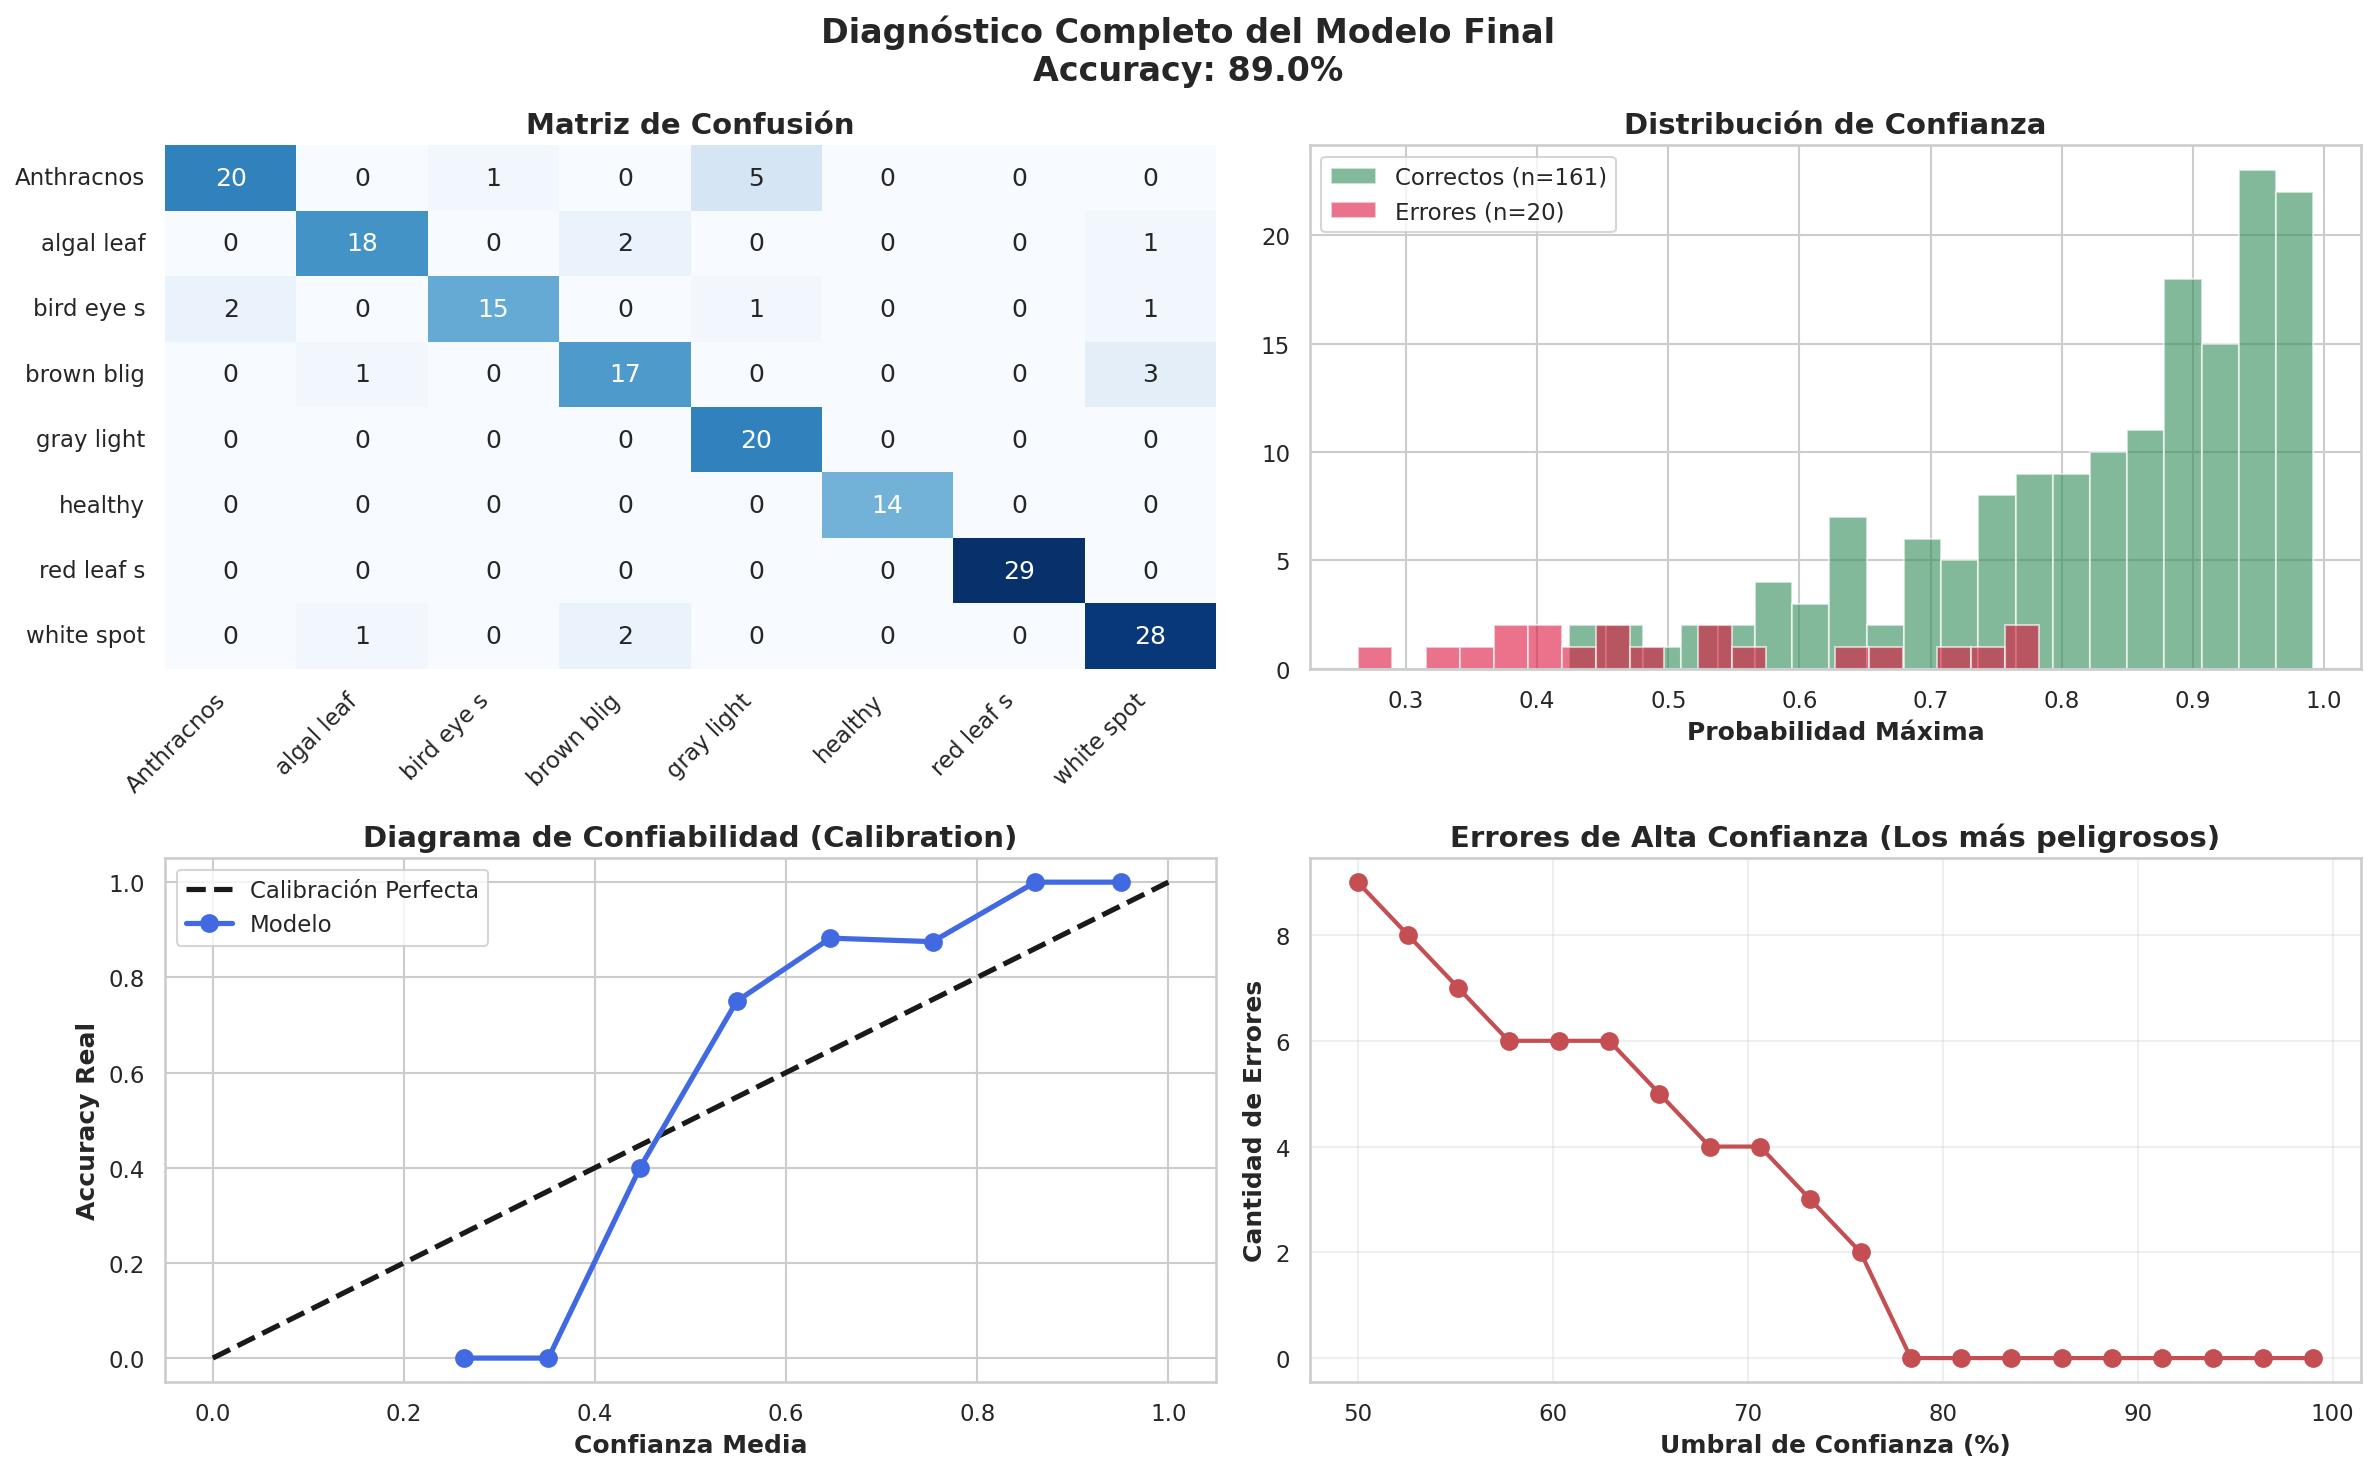

In [17]:
import seaborn as sns
def full_diagnostic(modelo, ds_val, class_names):
    """Genera un dashboard de diagnóstico de nivel producción."""
    all_preds, all_probs, all_true = [], [], []

    for imgs, labels in ds_val:
        probs = modelo.predict(imgs, verbose=0)
        all_probs.extend(probs)
        all_preds.extend(np.argmax(probs, axis=1))
        all_true.extend(np.argmax(labels.numpy(), axis=1))  # para el Onehot al usar "categorical"

    all_true = np.array(all_true)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    confs = np.max(all_probs, axis=1)
    correct = (all_preds == all_true)

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(f'Diagnóstico Completo del Modelo Final\nAccuracy: {accuracy_score(all_true, all_preds)*100:.1f}%', fontsize=16, fontweight='bold')

    # 1. Matriz de Confusión
    ax1 = fig.add_subplot(2, 2, 1)
    cm = confusion_matrix(all_true, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False)
    ax1.set_xticklabels([c[:10] for c in class_names], rotation=45, ha='right')
    ax1.set_yticklabels([c[:10] for c in class_names], rotation=0)
    ax1.set_title('Matriz de Confusión')

    # 2. Distribución de Confianza
    ax2 = fig.add_subplot(2, 2, 2)
    ax2.hist(confs[correct], bins=20, alpha=0.6, color='seagreen', label=f'Correctos (n={correct.sum()})')
    ax2.hist(confs[~correct], bins=20, alpha=0.6, color='crimson', label=f'Errores (n={(~correct).sum()})')
    ax2.set_title('Distribución de Confianza')
    ax2.set_xlabel('Probabilidad Máxima')
    ax2.legend()

    # 3. Reliability Diagram (Calibración)
    ax3 = fig.add_subplot(2, 2, 3)
    n_bins = 10
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_accs, bin_confs = [], []

    for i in range(n_bins):
        mask = (confs >= bin_edges[i]) & (confs < bin_edges[i+1])
        if mask.sum() > 0:
            bin_accs.append(correct[mask].mean())
            bin_confs.append(confs[mask].mean())

    ax3.plot([0, 1], [0, 1], 'k--', label='Calibración Perfecta')
    ax3.plot(bin_confs, bin_accs, 'o-', color='royalblue', label='Modelo')
    ax3.set_title('Diagrama de Confiabilidad (Calibration)')
    ax3.set_xlabel('Confianza Media')
    ax3.set_ylabel('Accuracy Real')
    ax3.legend()

    # 4. Errores de Alta Confianza
    ax4 = fig.add_subplot(2, 2, 4)
    thresholds = np.linspace(0.5, 0.99, 20)
    n_errors = [((~correct) & (confs >= t)).sum() for t in thresholds]
    ax4.plot(thresholds * 100, n_errors, 'r-o', lw=2)
    ax4.set_title('Errores de Alta Confianza (Los más peligrosos)')
    ax4.set_xlabel('Umbral de Confianza (%)')
    ax4.set_ylabel('Cantidad de Errores')
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Ejecutamos el diagnóstico
full_diagnostic(mejor_modelo, ds_val, class_names)

## Lecciones de Ingeniería y Checklist de Producción



Al observar el *Dashboard* de diagnóstico, un ingeniero debe evaluar lo siguiente:
1. **Expected Calibration Error (ECE):** Si la línea azul en el Diagrama de Confiabilidad está muy por debajo de la línea punteada negra, el modelo es **sobreconfiado**. Esto se mitiga usando *Label Smoothing* en la cabeza de clasificación (como hicimos en el modelo `Advanced`).
2. **Errores de Alta Confianza:** Si el modelo comete muchos errores estando 99% seguro, no podemos confiar en él para automatización total. Debemos establecer un umbral de rechazo (ej. para nuestro caso; derivar a un humano si la confianza es `< 58%`).

**Checklist antes de guardar el modelo (`.keras`):**
- [x] El modelo incluye la capa de *Data Augmentation* (solo activa en training).
- [x] El preprocesamiento específico del backbone (`eff_preprocess`) está integrado en el grafo.
- [x] Las capas `BatchNormalization` del backbone sobrevivieron al *Fine-Tuning* sin corromperse.

---


## Entorno de Ejecución


In [19]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.13
Platform,Linux-6.6.122+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
keras,3.13.2
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
